# Preprocessing Data Hotel Booking
Mata Kuliah Rekayasa Data

## 1. Setup Environment dan Konfigurasi Visual

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

# buat folder figures untuk menyimpan hasil visualisasi
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# konfigurasi tampilan grafik
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
})
sns.set_style("whitegrid")

# konfigurasi nama file
CSV_LOCAL = "hotel_booking_data.csv"
CSV_REMOTE = "https://huggingface.co/datasets/momentarek1/hotel_booking_data/resolve/main/hotel_booking_data.csv"
CSV_OUTPUT = "hotel_booking_preprocessed.csv"

# daftar kolom yang perlu dibuang
PII_COLS = ["name", "email", "phone-number", "credit_card"]
LEAKAGE_COLS = ["reservation_status", "reservation_status_date"]
SCRUB_COLS = PII_COLS + LEAKAGE_COLS

# daftar atribut numerik utama untuk analisis korelasi
NUM_FEATURES = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "booking_changes", "adr", "total_of_special_requests",
]

# daftar atribut untuk pca
PCA_FEATURES = [
    "lead_time", "total_stay_nights", "adults", "children",
    "booking_changes", "adr", "days_in_waiting_list", "total_of_special_requests",
]

# mapping bulan ke angka dan musim
MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}

SEASON_MAP = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}

print(f"Folder figures siap di: {FIGURES_DIR.resolve()}")

Folder figures siap di: C:\Belajar\Sem5\REKDAT\figures


## 2. Load Dataset dan Caching Lokal

In [2]:
# download file dari url jika belum ada di lokal
def download_if_absent(local_path, remote_url):
    if Path(local_path).exists():
        print(f"File {local_path} sudah ada di lokal.")
        return
    import requests
    print(f"Mengunduh file dari {remote_url}...")
    resp = requests.get(remote_url)
    resp.raise_for_status()
    Path(local_path).write_bytes(resp.content)
    print(f"Berhasil disimpan ke {local_path}")


# jalankan fungsi download dan muat data mentah
download_if_absent(CSV_LOCAL, CSV_REMOTE)
df_raw = pd.read_csv(CSV_LOCAL)
print(f"Data mentah berhasil dimuat: {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")

File hotel_booking_data.csv sudah ada di lokal.
Data mentah berhasil dimuat: 119,390 baris x 36 kolom


## 3. Audit Awal Kualitas Data (Discrepancy Detection)

In [3]:
# cek kolom yang memiliki nilai kosong
def audit_nulls(df):
    counts = df.isnull().sum()
    pct = (counts / len(df) * 100).round(4)
    summary = pd.DataFrame({"missing_count": counts, "missing_pct": pct})
    return summary[summary["missing_count"] > 0].sort_values("missing_count", ascending=False)


# deteksi nilai tidak valid dan baris duplikat
def audit_anomalies(df):
    total_guests = df["adults"] + df["children"].fillna(0) + df["babies"].fillna(0)
    scrub_cols_present = [c for c in SCRUB_COLS if c in df.columns]
    if scrub_cols_present:
        dup_count = df.drop(columns=scrub_cols_present).duplicated().sum()
    else:
        dup_count = df.duplicated().sum()
    return {
        "adr_negative": int((df["adr"] < 0).sum()),
        "adr_extreme_gt1000": int((df["adr"] > 1000).sum()),
        "zero_guests": int((total_guests == 0).sum()),
        "real_duplicates": int(dup_count),
    }


# tampilkan hasil audit data mentah
print("Tabel Missing Values:")
display(audit_nulls(df_raw))

print("\nDeteksi Anomali Nilai:")
anomalies = audit_anomalies(df_raw)
for k, v in anomalies.items():
    print(f"- {k}: {v:,}")

Tabel Missing Values:


,missing_count,missing_pct
company,112593,94.3069
agent,16340,13.6862
country,488,0.4087
children,4,0.0034



Deteksi Anomali Nilai:
- adr_negative: 1
- adr_extreme_gt1000: 1
- zero_guests: 180
- real_duplicates: 32,252


## 4. Pipeline Pembersihan dan Transformasi Data

In [4]:
# 1. hapus kolom pii dan data leakage
def scrub_pii_and_leakage(df):
    cols = [c for c in SCRUB_COLS if c in df.columns]
    out = df.drop(columns=cols)
    print(f"[1] Menghapus {len(cols)} kolom PII dan leakage: {cols}")
    return out


# 2. hapus baris duplikat riil setelah pii dibuang
def deduplicate_records(df):
    n_before = len(df)
    out = df.drop_duplicates()
    n_dropped = n_before - len(out)
    print(f"[2] Menghapus {n_dropped:,} baris duplikat riil")
    return out


# 3. filter nilai yang tidak masuk akal (adr negatif, adr > 1000, dan tamu = 0)
def filter_impossible_records(df):
    total_guests = df["adults"] + df["children"].fillna(0) + df["babies"].fillna(0)
    mask = (df["adr"] >= 0) & (df["adr"] <= 1000) & (total_guests > 0)
    out = df[mask].copy()
    n_dropped = len(df) - len(out)
    print(f"[3] Menghapus {n_dropped:,} baris anomali (ADR invalid atau 0 tamu)")
    return out


# 4. imputasi nilai kosong pada children, country, agent, dan company
def impute_missing_values(df):
    out = df.copy()
    out["children"] = out["children"].fillna(0).astype(int)
    out["country"] = out["country"].fillna("Unknown")
    out["agent"] = out["agent"].fillna(0)
    out["company"] = out["company"].fillna(0)
    sisa_null = out.isnull().sum().sum()
    print(f"[4] Imputasi selesai. Sisa missing values: {sisa_null}")
    return out


# 5. ekstraksi fitur baru: total malam menginap dan indikator kamar diubah
def extract_domain_features(df):
    out = df.copy()
    out["total_stay_nights"] = out["stays_in_weekend_nights"] + out["stays_in_week_nights"]
    out["is_room_changed"] = (out["reserved_room_type"] != out["assigned_room_type"]).astype(int)
    print("[5] Fitur baru berhasil dibuat: total_stay_nights dan is_room_changed")
    return out


# 6. diskretisasi lead time dan pembuatan hierarki tanggal kedatangan
def discretize_temporal_features(df):
    out = df.copy()

    # diskretisasi lead time menggunakan 4 kuantil (equal-frequency)
    out["lead_time_category"] = pd.qcut(
        out["lead_time"], q=4,
        labels=["Very Short", "Short", "Medium", "Long"],
    )

    # buat hierarki konsep tanggal kedatangan
    month_num = out["arrival_date_month"].map(MONTH_MAP)
    out["arrival_date"] = pd.to_datetime(
        out["arrival_date_year"].astype(str)
        + "-" + month_num.astype(str).str.zfill(2)
        + "-" + out["arrival_date_day_of_month"].astype(str).str.zfill(2)
    )
    out["arrival_quarter"] = "Q" + out["arrival_date"].dt.quarter.astype(str)
    out["arrival_season"] = month_num.map(SEASON_MAP)

    print("[6] Diskretisasi lead_time dan hierarki tanggal selesai dibuat")
    return out


# eksekusi seluruh tahapan pipeline secara berurutan menggunakan .pipe()
df_clean = (
    df_raw
    .pipe(scrub_pii_and_leakage)
    .pipe(deduplicate_records)
    .pipe(filter_impossible_records)
    .pipe(impute_missing_values)
    .pipe(extract_domain_features)
    .pipe(discretize_temporal_features)
)

print(f"\nHasil data bersih (df_clean): {df_clean.shape[0]:,} baris x {df_clean.shape[1]} kolom")

[1] Menghapus 6 kolom PII dan leakage: ['name', 'email', 'phone-number', 'credit_card', 'reservation_status', 'reservation_status_date']
[2] Menghapus 32,252 baris duplikat riil
[3] Menghapus 168 baris anomali (ADR invalid atau 0 tamu)
[4] Imputasi selesai. Sisa missing values: 0
[5] Fitur baru berhasil dibuat: total_stay_nights dan is_room_changed
[6] Diskretisasi lead_time dan hierarki tanggal selesai dibuat

Hasil data bersih (df_clean): 86,970 baris x 36 kolom


## 5. Integrasi Data dan Uji Redundansi

In [5]:
# uji chi-square untuk melihat asosiasi tipe kamar yang dipesan vs diberikan
observed = pd.crosstab(df_clean["reserved_room_type"], df_clean["assigned_room_type"])
chi2_stat, p_value, dof, expected = chi2_contingency(observed)

print("Hasil Uji Chi-Square (reserved_room_type vs assigned_room_type):")
print(f"- Nilai Chi-Square : {chi2_stat:,.4f}")
print(f"- Nilai p-value    : {p_value:.4e}")
print(f"- Derajat Kebebasan: {dof}")

print("\nTabel Kontingensi Observasi:")
display(observed)

print("\nTabel Frekuensi Ekspektasi:")
expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
display(expected_df.round(2))

# analisis korelasi pearson untuk fitur numerik
corr_matrix = df_clean[NUM_FEATURES].corr()
print("\nMatriks Korelasi Pearson:")
display(corr_matrix.round(4))

# cari pasangan atribut dengan korelasi tertinggi
top_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .unstack()
    .dropna()
    .sort_values(ascending=False)
    .head(5)
)
print("\nTop 5 Pasangan Korelasi Tertinggi:")
display(top_corr)

Hasil Uji Chi-Square (reserved_room_type vs assigned_room_type):
- Nilai Chi-Square : 387,036.7100
- Nilai p-value    : 0.0000e+00
- Derajat Kebebasan: 80

Tabel Kontingensi Observasi:


assigned_room_type,A,B,C,D,E,F,G,H,I,K,L
reserved_room_type,,,,,,,,,,,
A,45646,890,1252,6400,1034,390,176,93,205,140,0
B,106,872,0,5,2,2,8,0,0,1,0
C,5,2,865,6,4,2,10,9,10,0,0
D,295,27,32,15945,657,199,82,9,67,29,0
E,15,2,6,22,5448,383,97,4,40,9,0
F,6,14,0,4,31,2634,113,3,10,3,0
G,5,1,2,0,4,14,1996,7,15,3,0
H,0,0,0,1,0,0,10,579,6,0,0
L,1,1,1,0,0,1,0,1,0,0,1



Tabel Frekuensi Ekspektasi:


assigned_room_type,A,B,C,D,E,F,G,H,I,K,L
reserved_room_type,,,,,,,,,,,
A,29790.02,1169.52,1395.14,14470.58,4641.86,2343.56,1611.07,455.78,228.21,119.60,0.65
B,527.71,20.72,24.71,256.34,82.23,41.51,28.54,8.07,4.04,2.12,0.01
C,483.73,18.99,22.65,234.97,75.37,38.05,26.16,7.40,3.71,1.94,0.01
D,9188.25,360.72,430.31,4463.22,1431.71,722.83,496.91,140.58,70.39,36.89,0.20
E,3192.73,125.34,149.52,1550.88,497.49,251.17,172.67,48.85,24.46,12.82,0.07
F,1493.05,58.62,69.92,725.25,232.65,117.46,80.75,22.84,11.44,5.99,0.03
G,1084.55,42.58,50.79,526.83,168.99,85.32,58.65,16.59,8.31,4.35,0.02
H,315.78,12.40,14.79,153.39,49.20,24.84,17.08,4.83,2.42,1.27,0.01
L,3.18,0.12,0.15,1.54,0.50,0.25,0.17,0.05,0.02,0.01,0.00



Matriks Korelasi Pearson:


,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,booking_changes,adr,total_of_special_requests
lead_time,1.0000,0.2373,0.3139,0.1391,0.0291,0.0816,0.0247,0.0351
stays_in_weekend_nights,0.2373,1.0000,0.5500,0.0917,0.0290,0.0345,0.0444,0.0327
stays_in_week_nights,0.3139,0.5500,1.0000,0.0995,0.0312,0.0664,0.0599,0.0383
adults,0.1391,0.0917,0.0995,1.0000,0.0221,-0.0365,0.2557,0.1126
children,0.0291,0.0290,0.0312,0.0221,1.0000,0.0334,0.3453,0.0444
booking_changes,0.0816,0.0345,0.0664,-0.0365,0.0334,1.0000,0.0094,0.0179
adr,0.0247,0.0444,0.0599,0.2557,0.3453,0.0094,1.0000,0.1463
total_of_special_requests,0.0351,0.0327,0.0383,0.1126,0.0444,0.0179,0.1463,1.0000



Top 5 Pasangan Korelasi Tertinggi:


stays_in_week_nights     stays_in_weekend_nights    0.549976
adr                      children                   0.345340
stays_in_week_nights     lead_time                  0.313860
adr                      adults                     0.255733
stays_in_weekend_nights  lead_time                  0.237324
dtype: float64

### Analisis Redundansi Data
- Chi-Square: reserved vs assigned room memiliki p-value < 0.001 (asosiasi signifikan). Kedua atribut dipertahankan untuk mendeteksi room upgrade/downgrade.
- Korelasi Pearson: Korelasi tertinggi r = 0.550 (stays_in_weekend_nights vs stays_in_week_nights). Tidak ada korelasi ekstrem (|r| >= 0.85), seluruh 8 fitur numerik dipertahankan.

## 6. Reduksi Dimensi dengan PCA (Principal Component Analysis)

In [6]:
# fungsi untuk standardisasi z-score dan fitting pca
def run_pca_analysis(df, features):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    return X_pca, pca, scaler


# jalankan pca pada 8 fitur numerik pilihan
X_pca, pca_model, scaler = run_pca_analysis(df_clean, PCA_FEATURES)

# hitung rasio varians individual dan kumulatif
evr = pca_model.explained_variance_ratio_
cum_evr = np.cumsum(evr) * 100

pca_summary = pd.DataFrame({
    "Komponen": [f"PC{i+1}" for i in range(len(PCA_FEATURES))],
    "Eigenvalue": pca_model.explained_variance_.round(4),
    "Varians_Persen": (evr * 100).round(2),
    "Varians_Kumulatif": cum_evr.round(2),
})

print("Tabel Ringkasan Varians PCA:")
display(pca_summary)

# cek berapa komponen yang dibutuhkan untuk mencapai batas minimal 70% varians
n_components_70 = int(np.argmax(cum_evr >= 70)) + 1
print(f"\nJumlah komponen yang dibutuhkan untuk mencapai >= 70% varians: {n_components_70} komponen (kumulatif: {cum_evr[n_components_70 - 1]:.2f}%)")

Tabel Ringkasan Varians PCA:


,Komponen,Eigenvalue,Varians_Persen,Varians_Kumulatif
0,PC1,1.6059,20.07,20.07
1,PC2,1.3138,16.42,36.50
2,PC3,1.0584,13.23,49.73
3,PC4,1.0013,12.52,62.24
4,PC5,0.9458,11.82,74.06
5,PC6,0.8549,10.69,84.75
6,PC7,0.6545,8.18,92.93
7,PC8,0.5654,7.07,100.00



Jumlah komponen yang dibutuhkan untuk mencapai >= 70% varians: 5 komponen (kumulatif: 74.06%)


### Hasil PCA
- Varians kumulatif 2 komponen awal (PC1 + PC2): 36.50%.
- Batas retensi varians >= 70% tercapai pada PC5 (kumulatif 74.06%).
- Proyeksi 2D numerik menunjukkan kelas pembatalan masih saling tumpang tindih.

## 7. Ekspor Aset Visual dan Penyimpanan Data Final

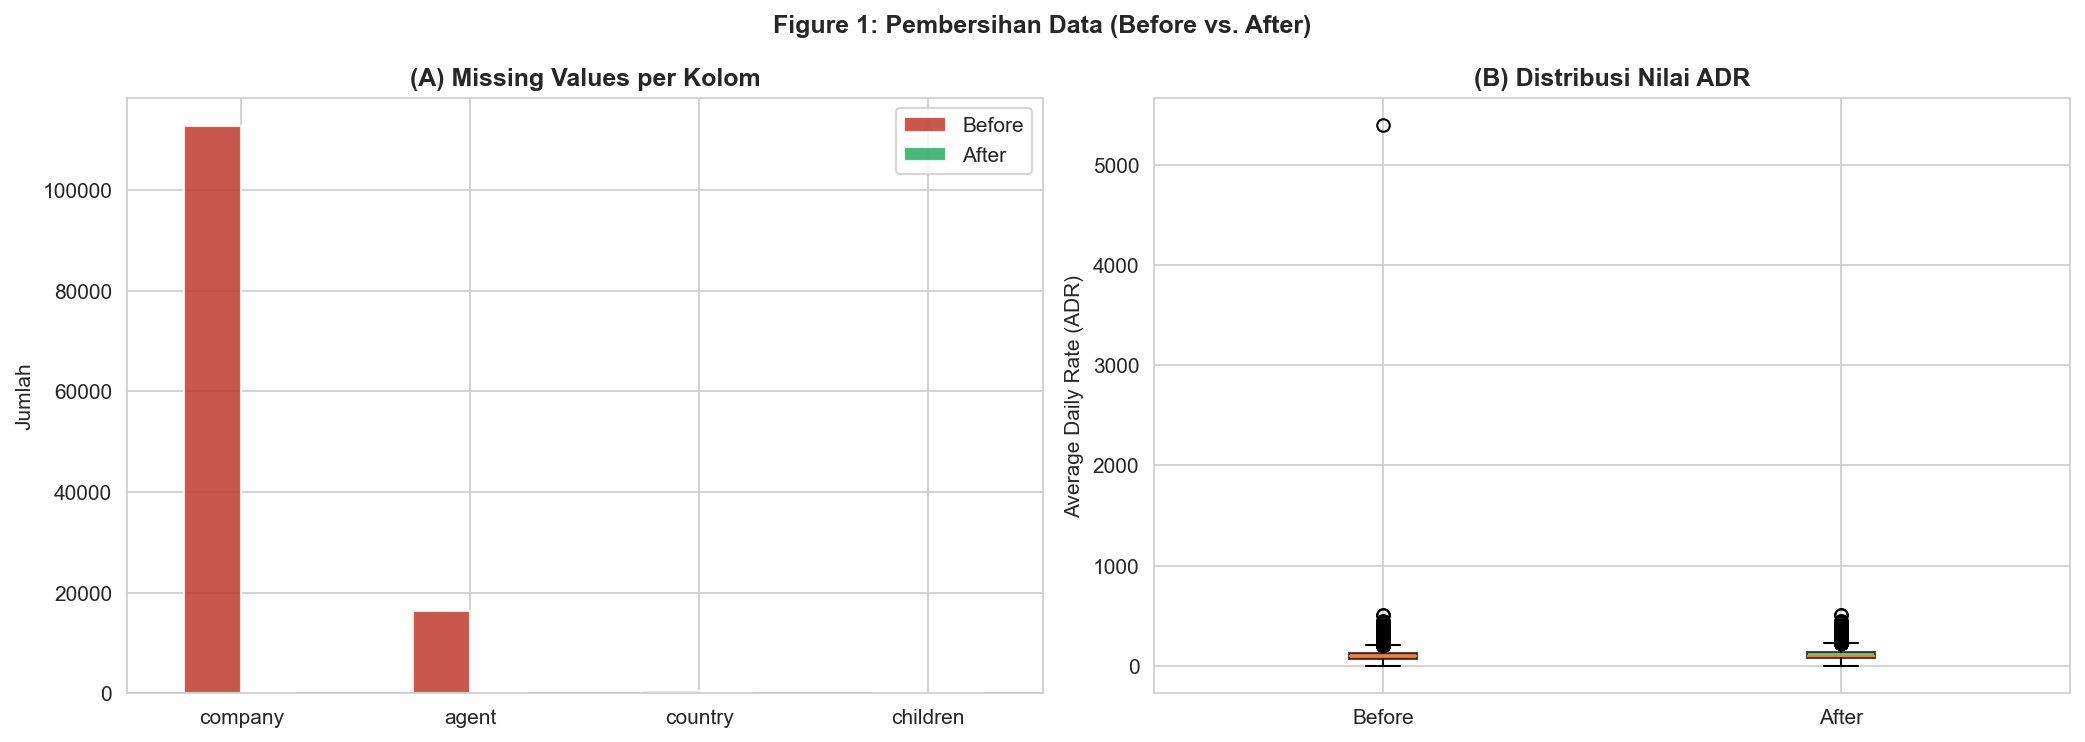

Berhasil ekspor: fig1_before_after_cleaning.png


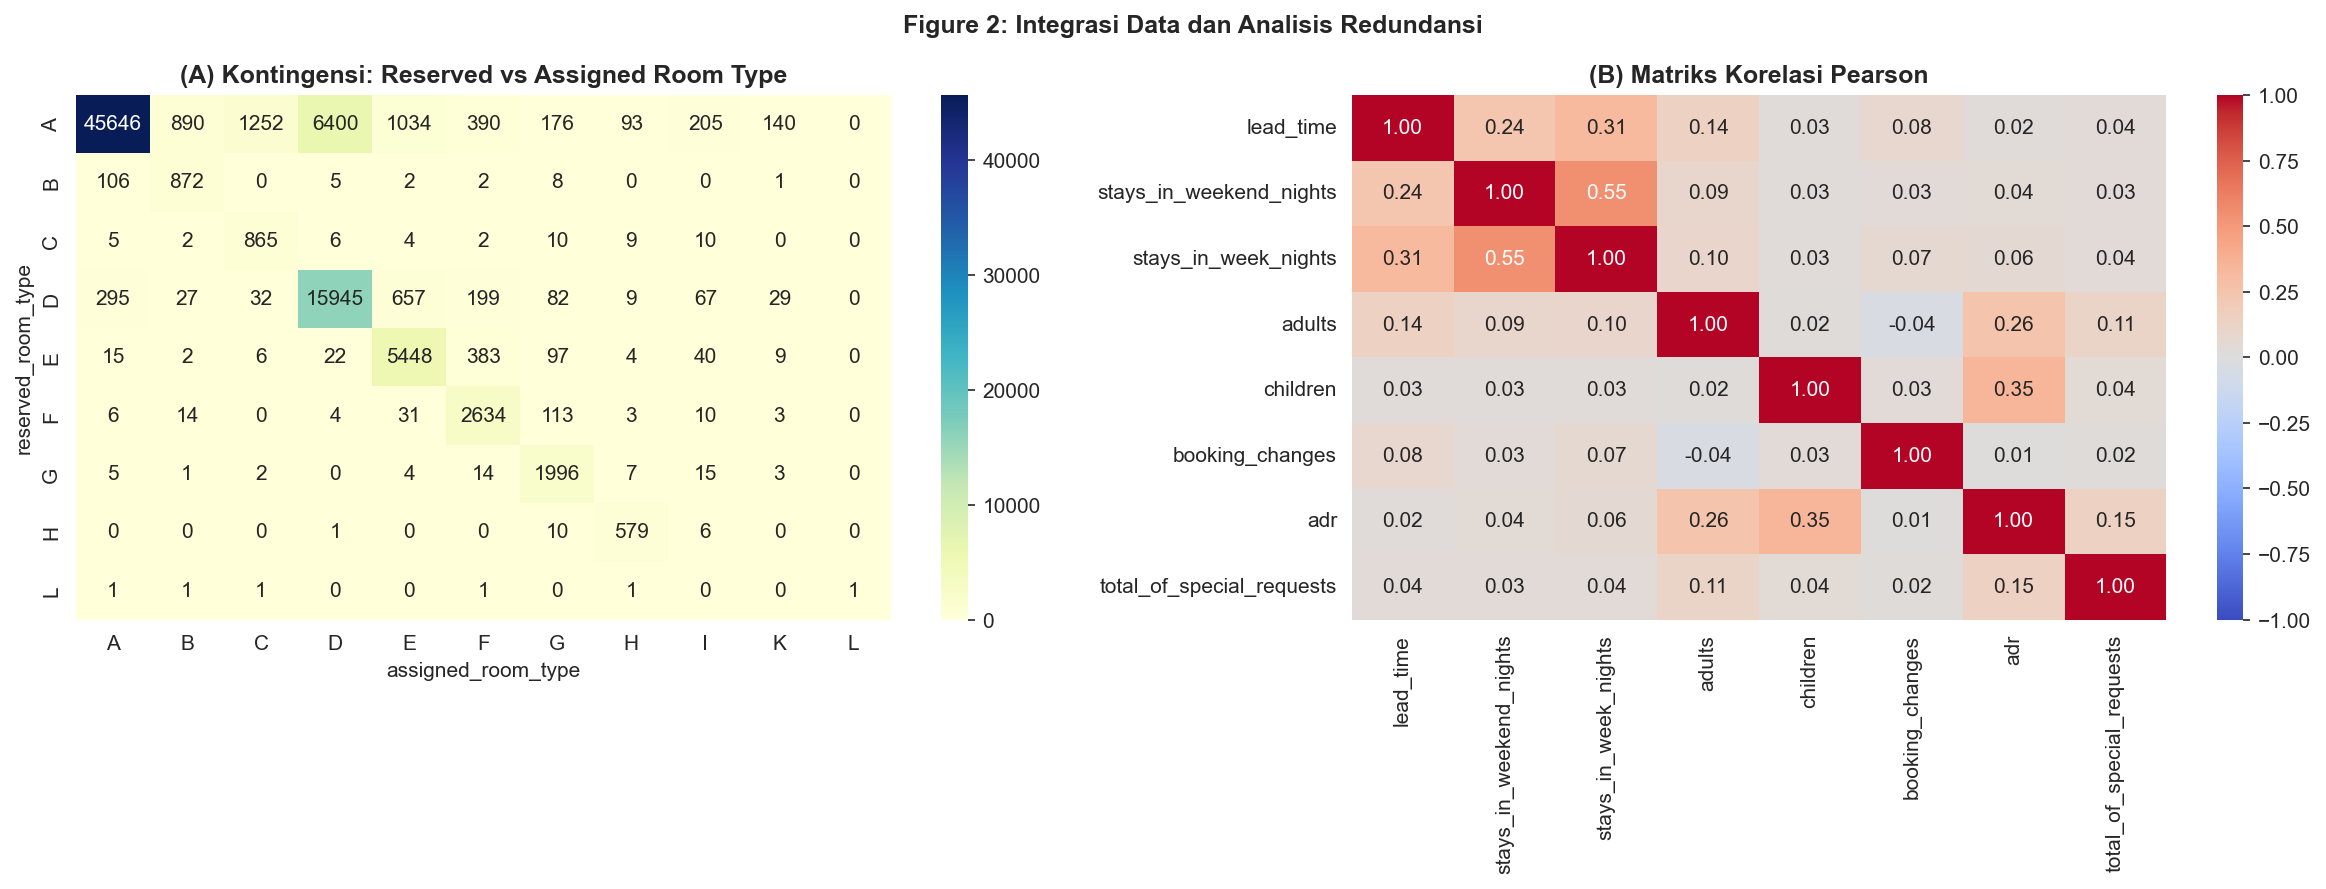

Berhasil ekspor: fig2_data_integration.png


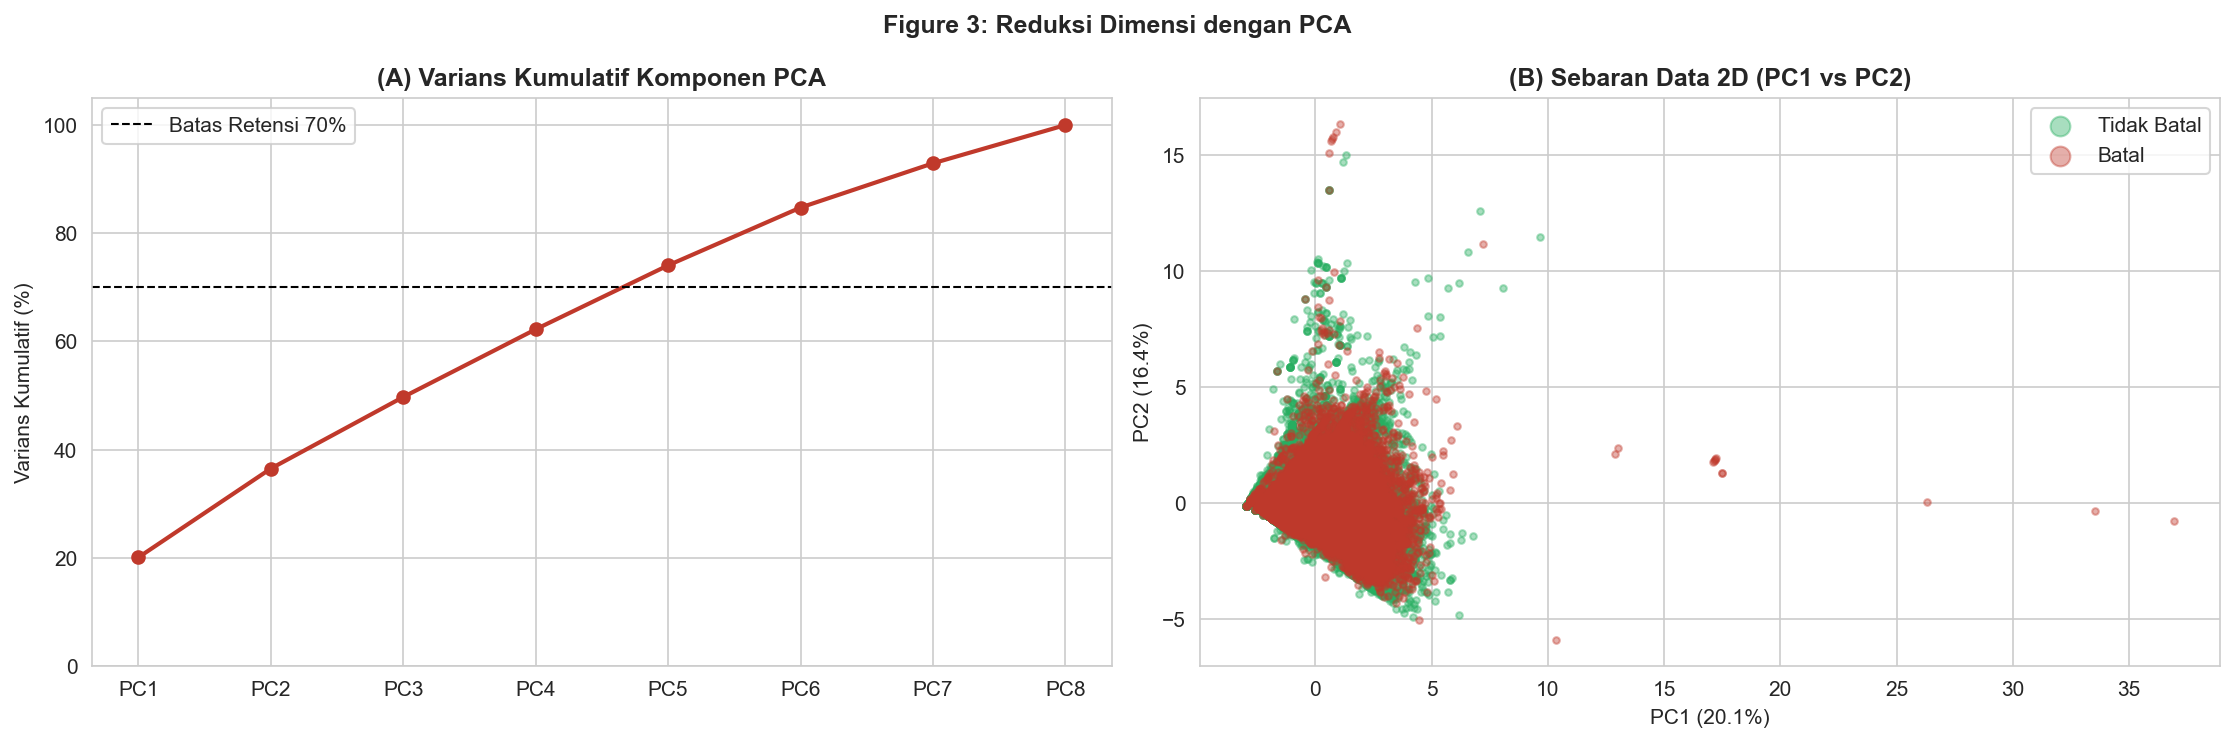

Berhasil ekspor: fig3_data_reduction_pca.png


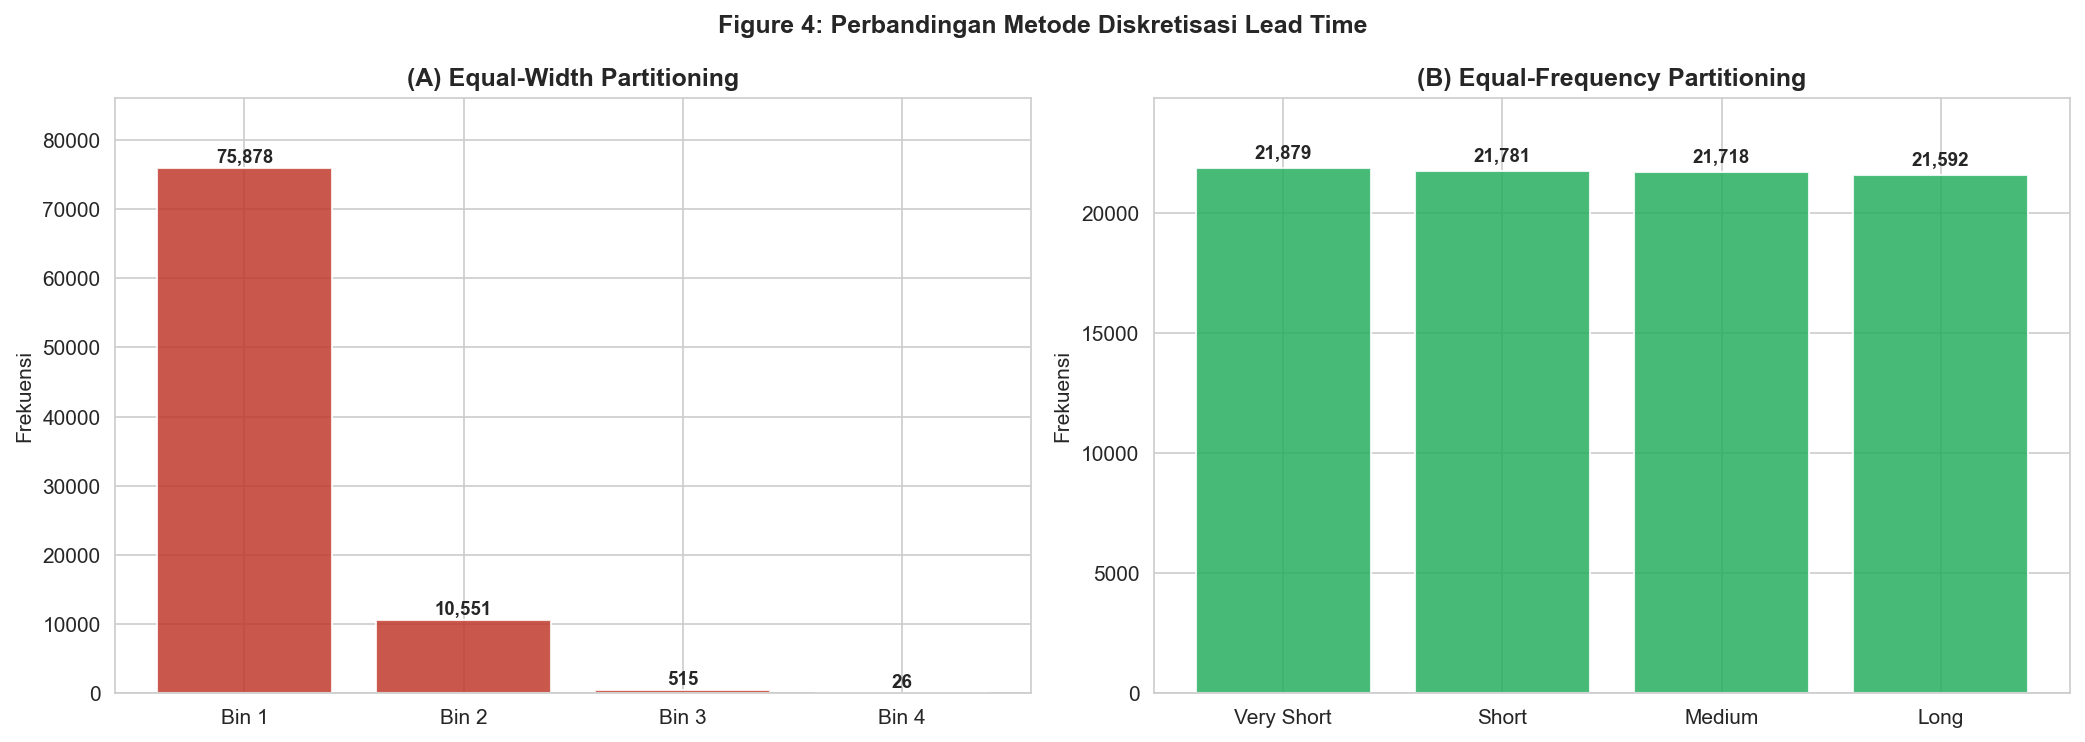

Berhasil ekspor: fig4_discretization_binning.png

Tabel Perbandingan Before vs After (Format Markdown):
| Metrik                |   Before (df_raw) |   After (df_clean) |
|:----------------------|------------------:|-------------------:|
| Total Baris Data      |           119,390 |             86,970 |
| Total Kolom           |                36 |                 36 |
| Total Sel Kosong      |           129,425 |                  0 |
| Jumlah Baris Duplikat |            32,252 |                  0 |
| Nilai ADR Tidak Valid |                 2 |                  0 |
| Pemesanan 0 Tamu      |               180 |                  0 |


,Metrik,Before (df_raw),After (df_clean)
0,Total Baris Data,"119,390","86,970"
1,Total Kolom,36,36
2,Total Sel Kosong,"129,425",0
3,Jumlah Baris Duplikat,"32,252",0
4,Nilai ADR Tidak Valid,2,0
5,Pemesanan 0 Tamu,180,0



Dataset final berhasil disimpan ke: hotel_booking_preprocessed.csv (86,970 baris x 36 kolom)


In [7]:
# 1. figure 1: perbandingan data sebelum dan sesudah cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_cols = ["company", "agent", "country", "children"]
raw_miss = df_raw[missing_cols].isnull().sum()
clean_miss = df_clean[missing_cols].isnull().sum()
pd.DataFrame({"Before": raw_miss, "After": clean_miss}).plot(
    kind="bar", ax=axes[0], color=["#c0392b", "#27ae60"], alpha=0.85,
)
axes[0].set_title("(A) Missing Values per Kolom", fontweight="bold")
axes[0].set_ylabel("Jumlah")
axes[0].set_xticklabels(missing_cols, rotation=0)

bp = axes[1].boxplot(
    [df_raw["adr"].dropna(), df_clean["adr"]],
    tick_labels=["Before", "After"],
    patch_artist=True,
)
bp["boxes"][0].set_facecolor("#c0392b")
bp["boxes"][1].set_facecolor("#27ae60")
for box in bp["boxes"]:
    box.set_alpha(0.7)
axes[1].set_title("(B) Distribusi Nilai ADR", fontweight="bold")
axes[1].set_ylabel("Average Daily Rate (ADR)")

fig.suptitle("Figure 1: Pembersihan Data (Before vs. After)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_before_after_cleaning.png", dpi=300, bbox_inches="tight")
plt.show()
print("Berhasil ekspor: fig1_before_after_cleaning.png")


# 2. figure 2: hasil integrasi data dan analisis redundansi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(observed, ax=axes[0], annot=True, fmt="d", cmap="YlGnBu")
axes[0].set_title("(A) Kontingensi: Reserved vs Assigned Room Type", fontweight="bold")

sns.heatmap(corr_matrix, ax=axes[1], annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_title("(B) Matriks Korelasi Pearson", fontweight="bold")

fig.suptitle("Figure 2: Integrasi Data dan Analisis Redundansi", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_data_integration.png", dpi=300, bbox_inches="tight")
plt.show()
print("Berhasil ekspor: fig2_data_integration.png")


# 3. figure 3: hasil analisis pca
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pc_labels = [f"PC{i+1}" for i in range(len(PCA_FEATURES))]
axes[0].plot(pc_labels, cum_evr, color="#c0392b", marker="o", linewidth=2)
axes[0].axhline(y=70, color="black", linestyle="--", linewidth=1, label="Batas Retensi 70%")
axes[0].set_title("(A) Varians Kumulatif Komponen PCA", fontweight="bold")
axes[0].set_ylabel("Varians Kumulatif (%)")
axes[0].set_ylim(0, 105)
axes[0].legend()

scatter_df = pd.DataFrame({
    "PC1": X_pca[:, 0], "PC2": X_pca[:, 1],
    "is_canceled": df_clean["is_canceled"].values,
})
for label, color, name in [(0, "#27ae60", "Tidak Batal"), (1, "#c0392b", "Batal")]:
    subset = scatter_df[scatter_df["is_canceled"] == label]
    axes[1].scatter(
        subset["PC1"], subset["PC2"],
        c=color, alpha=0.4, s=10,
        label=name,
    )
axes[1].set_title("(B) Sebaran Data 2D (PC1 vs PC2)", fontweight="bold")
axes[1].set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
axes[1].legend(markerscale=3)

fig.suptitle("Figure 3: Reduksi Dimensi dengan PCA", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_data_reduction_pca.png", dpi=300, bbox_inches="tight")
plt.show()
print("Berhasil ekspor: fig3_data_reduction_pca.png")


# 4. figure 4: perbandingan diskretisasi lead time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

eq_width = pd.cut(df_clean["lead_time"], bins=4)
w_counts = eq_width.value_counts().sort_index()

lt_labels = ["Very Short", "Short", "Medium", "Long"]
f_counts = df_clean["lead_time_category"].value_counts()[lt_labels]

axes[0].bar(range(4), w_counts.values, color="#c0392b", alpha=0.85)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([f"Bin {i+1}" for i in range(4)])
axes[0].set_title("(A) Equal-Width Partitioning", fontweight="bold")
axes[0].set_ylabel("Frekuensi")
for i, v in enumerate(w_counts.values):
    axes[0].text(i, v + 800, f"{v:,}", ha="center", fontweight="bold", fontsize=9)
axes[0].set_ylim(top=axes[0].get_ylim()[1] * 1.08)

axes[1].bar(lt_labels, f_counts.values, color="#27ae60", alpha=0.85)
axes[1].set_title("(B) Equal-Frequency Partitioning", fontweight="bold")
axes[1].set_ylabel("Frekuensi")
for i, v in enumerate(f_counts.values):
    axes[1].text(i, v + 400, f"{v:,}", ha="center", fontweight="bold", fontsize=9)
axes[1].set_ylim(top=axes[1].get_ylim()[1] * 1.08)

fig.suptitle("Figure 4: Perbandingan Metode Diskretisasi Lead Time", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig4_discretization_binning.png", dpi=300, bbox_inches="tight")
plt.show()
print("Berhasil ekspor: fig4_discretization_binning.png")


# 5. tabel perbandingan kuantitatif before vs after
raw_anom = audit_anomalies(df_raw)

comparison = pd.DataFrame({
    "Metrik": [
        "Total Baris Data",
        "Total Kolom",
        "Total Sel Kosong",
        "Jumlah Baris Duplikat",
        "Nilai ADR Tidak Valid",
        "Pemesanan 0 Tamu",
    ],
    "Before (df_raw)": [
        f"{len(df_raw):,}",
        str(df_raw.shape[1]),
        f"{df_raw.isnull().sum().sum():,}",
        f"{raw_anom['real_duplicates']:,}",
        f"{raw_anom['adr_negative'] + raw_anom['adr_extreme_gt1000']:,}",
        f"{raw_anom['zero_guests']:,}",
    ],
    "After (df_clean)": [
        f"{len(df_clean):,}",
        str(df_clean.shape[1]),
        "0",
        "0",
        "0",
        "0",
    ],
})

print("\nTabel Perbandingan Before vs After (Format Markdown):")
print(comparison.to_markdown(index=False))
display(comparison)


# 6. simpan data hasil olahan ke file csv
df_clean.to_csv(CSV_OUTPUT, index=False)
print(f"\nDataset final berhasil disimpan ke: {CSV_OUTPUT} ({df_clean.shape[0]:,} baris x {df_clean.shape[1]} kolom)")